# Southern Women Network Analysis
## Davis Southern Club Women Dataset (1941)

### Marc Fridson | CUNY SPS

---

## 1. Brief Description

The Davis Southern Women dataset originates from a 1941 study by Davis, Gardner, and Gardner (*Deep South*), documenting the attendance of 18 women at 14 social events in Natchez, Mississippi during the 1930s. This is a classic **bipartite (two-mode) network**: one set of nodes represents women, the other represents events, and edges connect a woman to each event she attended.

Despite its small size, this "musty" dataset has become a benchmark for testing network analysis algorithms, particularly those involving:

- Bipartite network projection
- Community detection
- Clustering and cohesive subgroup identification

Its enduring value lies in the known ground truth: researchers have consistently identified two core social groups among the women, making it an ideal test case for validating new methods.

---

## 2. Setup and Data Loading

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from networkx.algorithms import bipartite
import community as community_louvain
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

In [2]:
# Load the Davis Southern Women dataset from NetworkX
# Reference: https://networkx.github.io/documentation/stable/auto_examples/algorithms/plot_davis_club.html
G = nx.davis_southern_women_graph()

# Identify the two node sets in the bipartite network
women = {n for n, d in G.nodes(data=True) if d['bipartite'] == 0}
events = set(G) - women

print(f"Number of women: {len(women)}")
print(f"Number of events: {len(events)}")
print(f"Number of edges (attendances): {G.number_of_edges()}")
print(f"\nWomen: {sorted(women)}")
print(f"\nEvents: {sorted(events)}")

Number of women: 18
Number of events: 14
Number of edges (attendances): 89

Women: ['Brenda Rogers', 'Charlotte McDowd', 'Dorothy Murchison', 'Eleanor Nye', 'Evelyn Jefferson', 'Flora Price', 'Frances Anderson', 'Helen Lloyd', 'Katherina Rogers', 'Laura Mandeville', 'Myra Liddel', 'Nora Fayette', 'Olivia Carleton', 'Pearl Oglethorpe', 'Ruth DeSand', 'Sylvia Avondale', 'Theresa Anderson', 'Verne Sanderson']

Events: ['E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9']


## 3. Bipartite Network Visualization

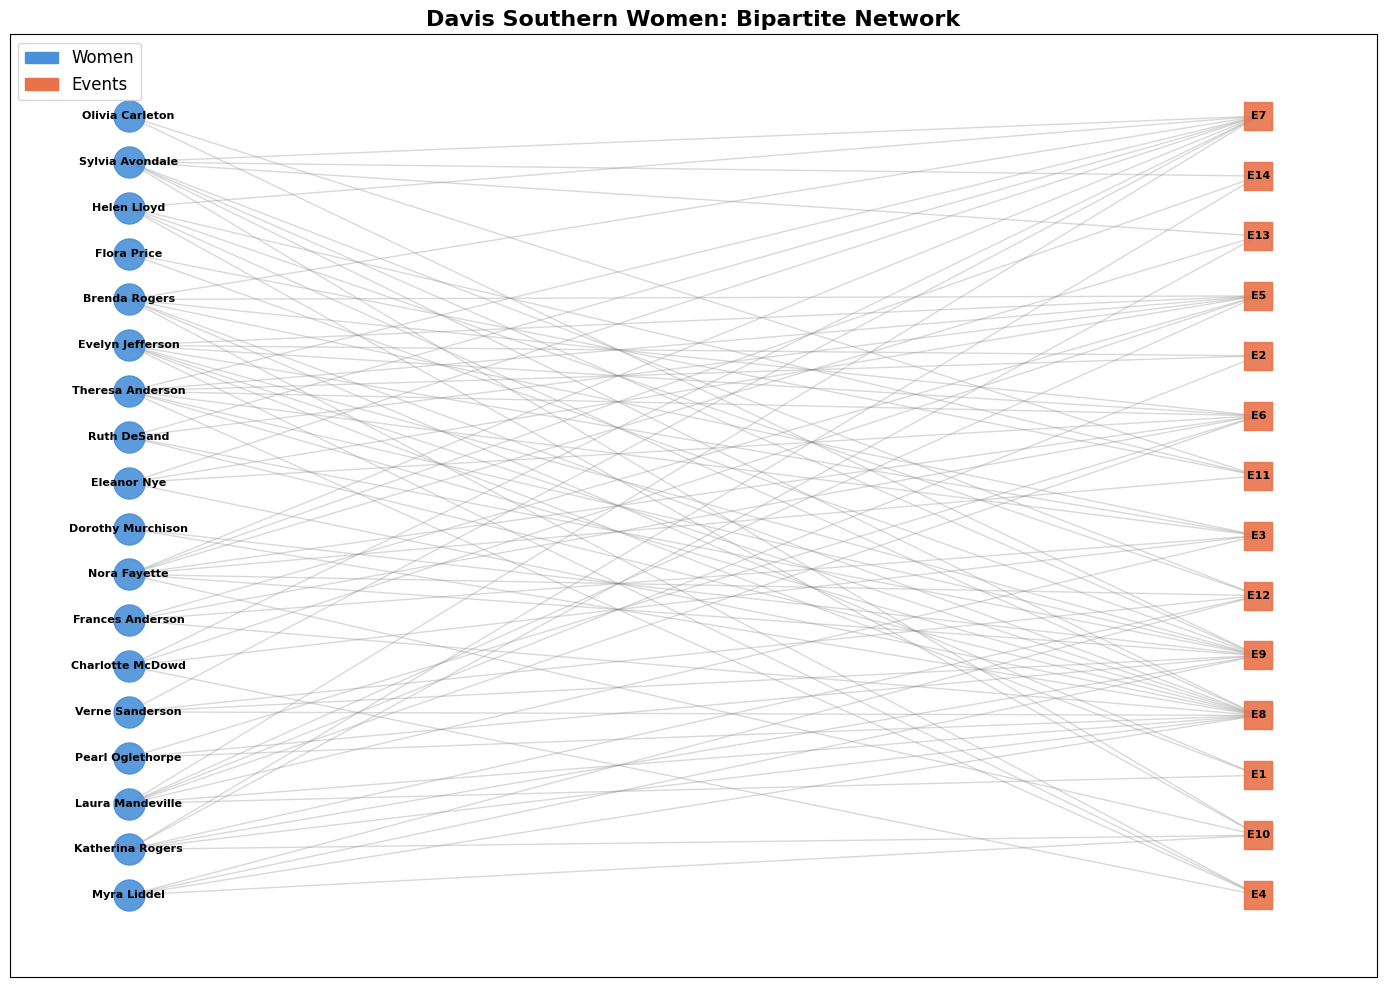

In [3]:
# Visualize the full bipartite network
fig, ax = plt.subplots(figsize=(14, 10))

pos = nx.bipartite_layout(G, women, align='vertical', scale=2)

nx.draw_networkx_nodes(G, pos, nodelist=sorted(women), node_color='#4A90D9',
                       node_size=500, alpha=0.9, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=sorted(events), node_color='#E8724A',
                       node_size=400, node_shape='s', alpha=0.9, ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

blue_patch = mpatches.Patch(color='#4A90D9', label='Women')
orange_patch = mpatches.Patch(color='#E8724A', label='Events')
ax.legend(handles=[blue_patch, orange_patch], loc='upper left', fontsize=12)
ax.set_title('Davis Southern Women: Bipartite Network', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Attendance Matrix

The bipartite adjacency matrix shows which women attended which events. This is the raw data underlying all subsequent projections.

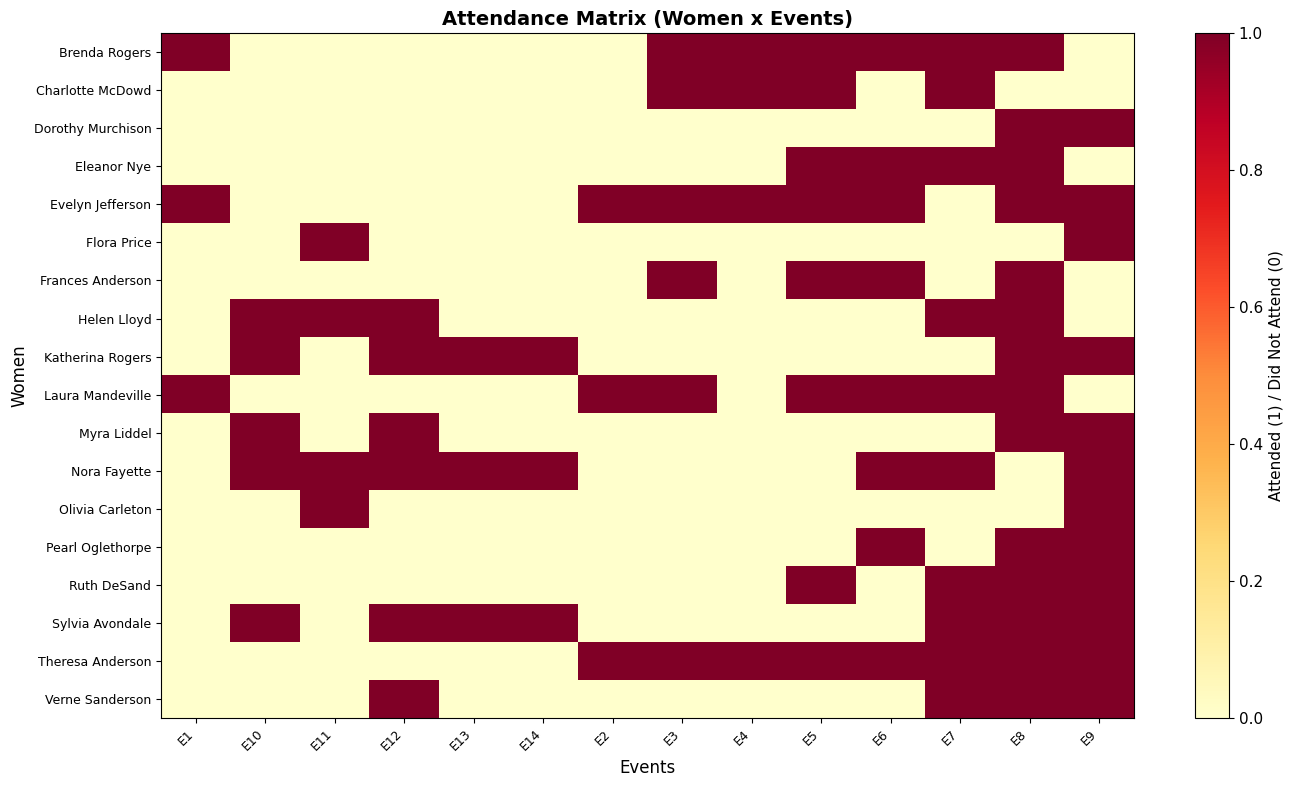

Events attended per woman:
  Brenda Rogers: 7
  Charlotte McDowd: 4
  Dorothy Murchison: 2
  Eleanor Nye: 4
  Evelyn Jefferson: 8
  Flora Price: 2
  Frances Anderson: 4
  Helen Lloyd: 5
  Katherina Rogers: 6
  Laura Mandeville: 7
  Myra Liddel: 4
  Nora Fayette: 8
  Olivia Carleton: 2
  Pearl Oglethorpe: 3
  Ruth DeSand: 4
  Sylvia Avondale: 7
  Theresa Anderson: 8
  Verne Sanderson: 4

Women per event:
  E1: 3
  E10: 5
  E11: 4
  E12: 6
  E13: 3
  E14: 3
  E2: 3
  E3: 6
  E4: 4
  E5: 8
  E6: 8
  E7: 10
  E8: 14
  E9: 12


In [4]:
# Build and display the attendance matrix
women_sorted = sorted(women)
events_sorted = sorted(events)

adj_matrix = bipartite.biadjacency_matrix(G, row_order=women_sorted, column_order=events_sorted).toarray()

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(adj_matrix, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(events_sorted)))
ax.set_xticklabels(events_sorted, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(women_sorted)))
ax.set_yticklabels(women_sorted, fontsize=9)
ax.set_xlabel('Events', fontsize=12)
ax.set_ylabel('Women', fontsize=12)
ax.set_title('Attendance Matrix (Women x Events)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='Attended (1) / Did Not Attend (0)')
plt.tight_layout()
plt.show()

# Attendance summary
print("Events attended per woman:")
for i, w in enumerate(women_sorted):
    print(f"  {w}: {adj_matrix[i].sum():.0f}")

print(f"\nWomen per event:")
for j, e in enumerate(events_sorted):
    print(f"  {e}: {adj_matrix[:, j].sum():.0f}")

## 5. Projection 1: Women-to-Women Network

We project the bipartite graph onto the women nodes. Two women are connected if they co-attended at least one event, with edge weight equal to the number of shared events.

In [5]:
# Project onto women (weighted by shared events)
W = bipartite.weighted_projected_graph(G, women)

print(f"Women network: {W.number_of_nodes()} nodes, {W.number_of_edges()} edges")
print(f"Density: {nx.density(W):.3f}")
print(f"\nEdge weights (shared events) for sample pairs:")
for u, v, d in sorted(W.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:10]:
    print(f"  {u} -- {v}: {d['weight']} shared events")

Women network: 18 nodes, 139 edges
Density: 0.908

Edge weights (shared events) for sample pairs:
  Theresa Anderson -- Evelyn Jefferson: 7 shared events
  Sylvia Avondale -- Katherina Rogers: 6 shared events
  Sylvia Avondale -- Nora Fayette: 6 shared events
  Theresa Anderson -- Laura Mandeville: 6 shared events
  Theresa Anderson -- Brenda Rogers: 6 shared events
  Laura Mandeville -- Evelyn Jefferson: 6 shared events
  Laura Mandeville -- Brenda Rogers: 6 shared events
  Evelyn Jefferson -- Brenda Rogers: 6 shared events
  Katherina Rogers -- Nora Fayette: 5 shared events
  Ruth DeSand -- Theresa Anderson: 4 shared events


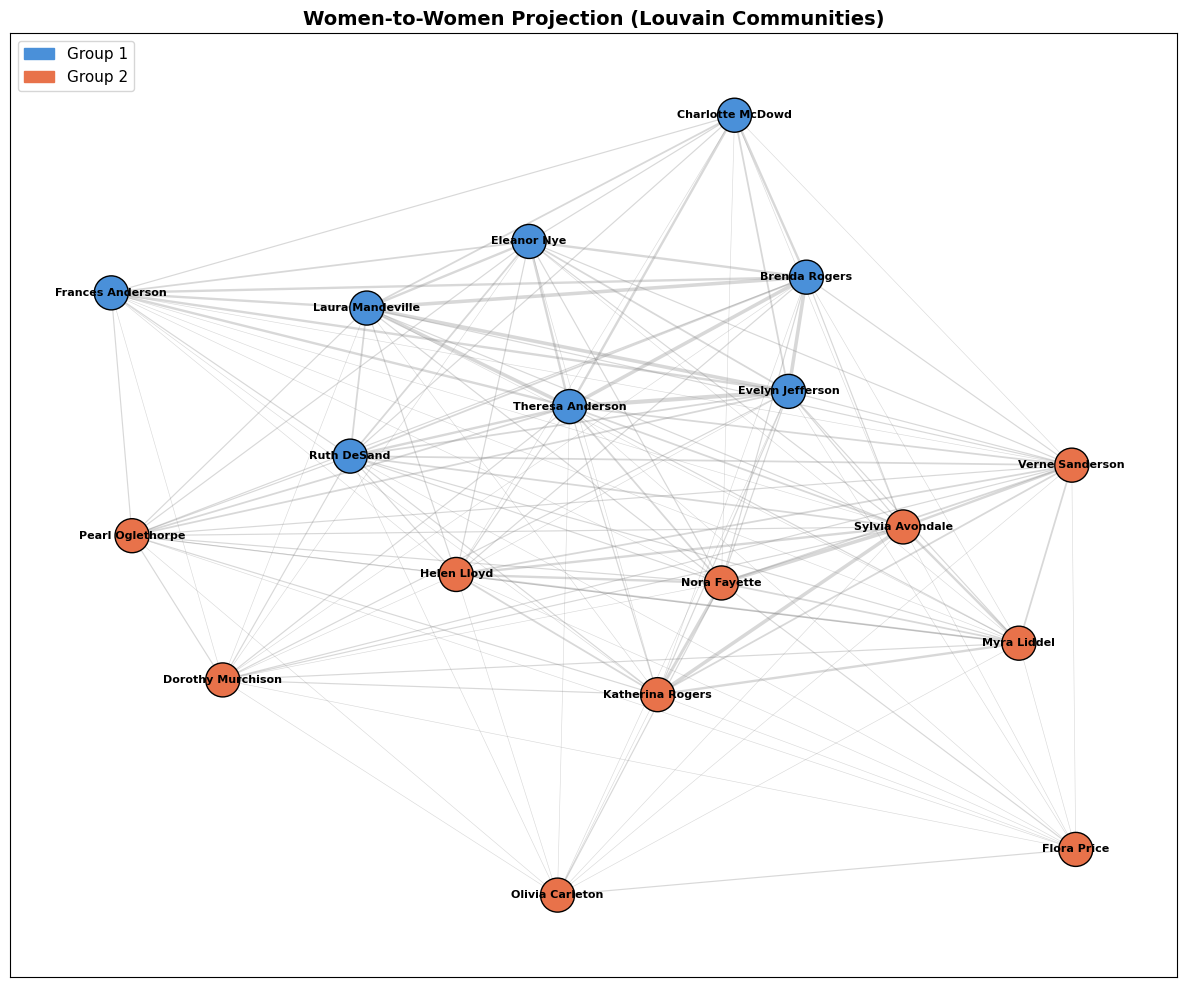

Group 1: ['Brenda Rogers', 'Charlotte McDowd', 'Eleanor Nye', 'Evelyn Jefferson', 'Frances Anderson', 'Laura Mandeville', 'Ruth DeSand', 'Theresa Anderson']
Group 2: ['Dorothy Murchison', 'Flora Price', 'Helen Lloyd', 'Katherina Rogers', 'Myra Liddel', 'Nora Fayette', 'Olivia Carleton', 'Pearl Oglethorpe', 'Sylvia Avondale', 'Verne Sanderson']


In [6]:
# Community detection on women network using Louvain
partition_women = community_louvain.best_partition(W, random_state=42)

# Assign colors by community
community_colors_map = {0: '#4A90D9', 1: '#E8724A', 2: '#50C878', 3: '#9B59B6'}
node_colors_w = [community_colors_map.get(partition_women[n], '#888888') for n in W.nodes()]

fig, ax = plt.subplots(figsize=(12, 10))
pos_w = nx.spring_layout(W, seed=42, k=0.8)

edges = W.edges(data=True)
edge_weights = [d['weight'] for _, _, d in edges]
max_w = max(edge_weights)

nx.draw_networkx_edges(W, pos_w, alpha=0.3, width=[w/max_w*3 for w in edge_weights],
                       edge_color='gray', ax=ax)
nx.draw_networkx_nodes(W, pos_w, node_color=node_colors_w, node_size=600, 
                       edgecolors='black', linewidths=1.0, ax=ax)
nx.draw_networkx_labels(W, pos_w, font_size=8, font_weight='bold', ax=ax)

# Legend
communities = set(partition_women.values())
patches = [mpatches.Patch(color=community_colors_map[c], label=f'Group {c+1}') for c in sorted(communities)]
ax.legend(handles=patches, loc='upper left', fontsize=11)
ax.set_title('Women-to-Women Projection (Louvain Communities)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print communities
for c in sorted(communities):
    members = [n for n, comm in partition_women.items() if comm == c]
    print(f"Group {c+1}: {sorted(members)}")

## 6. Centrality Analysis: Women Network

In [7]:
# Compute centrality measures for the women network
deg_cent_w = nx.degree_centrality(W)
betw_cent_w = nx.betweenness_centrality(W, weight='weight')
close_cent_w = nx.closeness_centrality(W)
eigen_cent_w = nx.eigenvector_centrality(W, weight='weight', max_iter=1000)

print(f"{'Woman':<20} {'Degree':>8} {'Betweenness':>12} {'Closeness':>10} {'Eigenvector':>12}")
print("-" * 65)
for w in sorted(women):
    print(f"{w:<20} {deg_cent_w[w]:>8.3f} {betw_cent_w[w]:>12.3f} {close_cent_w[w]:>10.3f} {eigen_cent_w[w]:>12.3f}")

# Who are the most central women?
print(f"\nMost central by eigenvector: {max(eigen_cent_w, key=eigen_cent_w.get)}")
print(f"Most central by betweenness: {max(betw_cent_w, key=betw_cent_w.get)}")

Woman                  Degree  Betweenness  Closeness  Eigenvector
-----------------------------------------------------------------
Brenda Rogers           0.882        0.003      0.895        0.304
Charlotte McDowd        0.647        0.015      0.739        0.174
Dorothy Murchison       0.941        0.096      0.944        0.146
Eleanor Nye             0.882        0.005      0.895        0.239
Evelyn Jefferson        1.000        0.001      1.000        0.319
Flora Price             0.706        0.136      0.773        0.077
Frances Anderson        0.882        0.058      0.895        0.218
Helen Lloyd             1.000        0.062      1.000        0.207
Katherina Rogers        0.941        0.054      0.944        0.222
Laura Mandeville        0.882        0.003      0.895        0.300
Myra Liddel             0.941        0.054      0.944        0.198
Nora Fayette            1.000        0.011      1.000        0.253
Olivia Carleton         0.706        0.136      0.773        0.

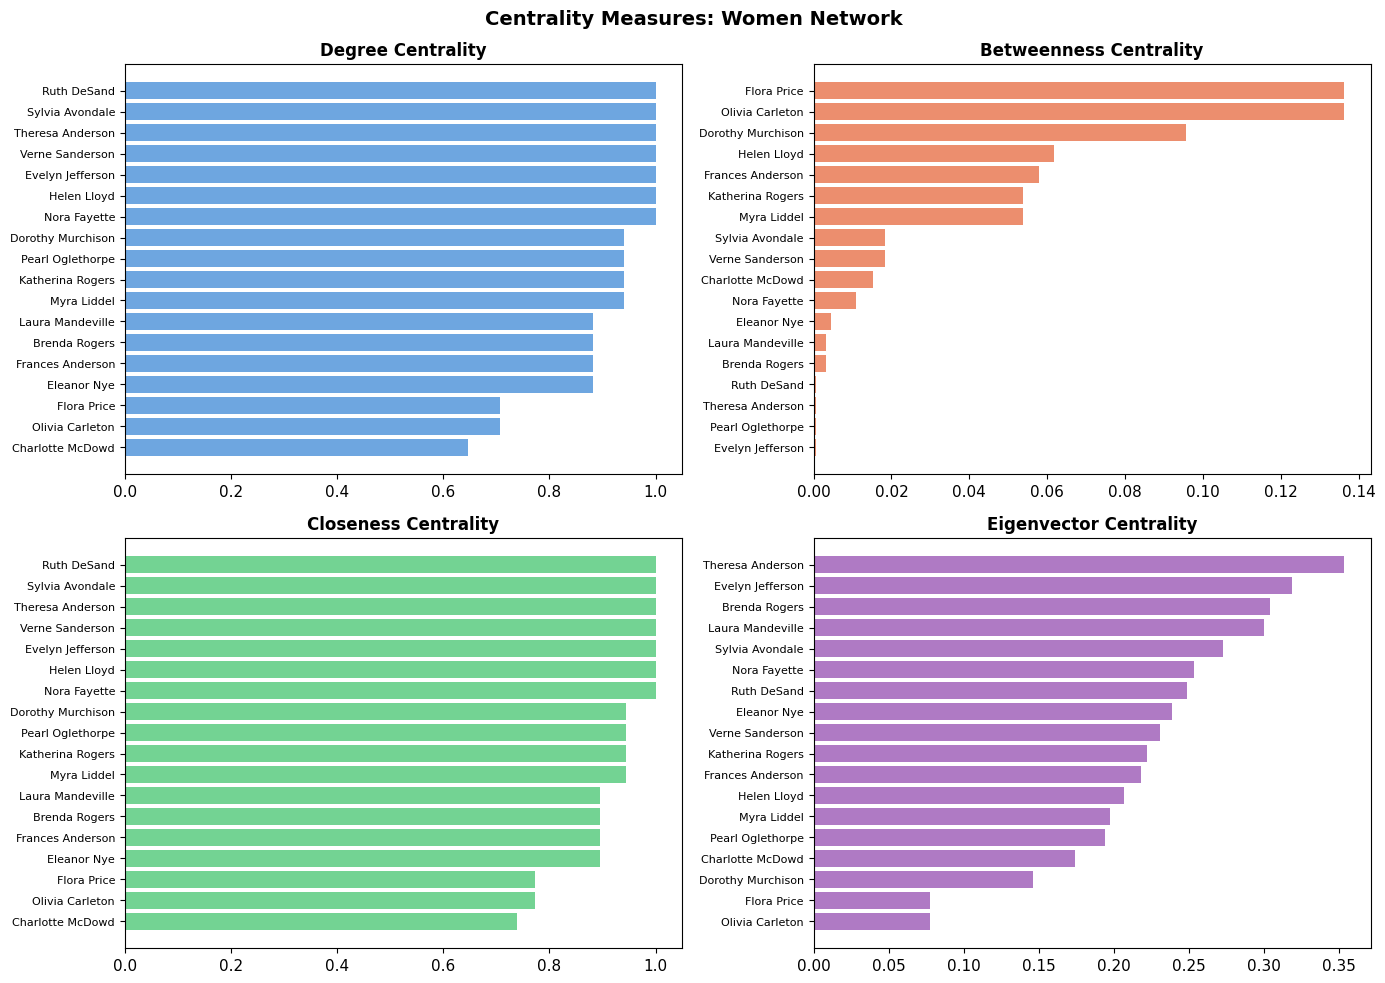

In [8]:
# Visualize centrality comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

centralities = [
    (deg_cent_w, 'Degree Centrality', '#4A90D9'),
    (betw_cent_w, 'Betweenness Centrality', '#E8724A'),
    (close_cent_w, 'Closeness Centrality', '#50C878'),
    (eigen_cent_w, 'Eigenvector Centrality', '#9B59B6')
]

for ax, (cent, title, color) in zip(axes.flatten(), centralities):
    sorted_items = sorted(cent.items(), key=lambda x: x[1], reverse=True)
    names = [x[0] for x in sorted_items]
    values = [x[1] for x in sorted_items]
    ax.barh(range(len(names)), values, color=color, alpha=0.8)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.invert_yaxis()

plt.suptitle('Centrality Measures: Women Network', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Projection 2: Event-to-Event Network

We now project onto the event nodes. Two events are connected if they share at least one attendee, with edge weight equal to the number of shared women.

Events network: 14 nodes, 66 edges
Density: 0.725


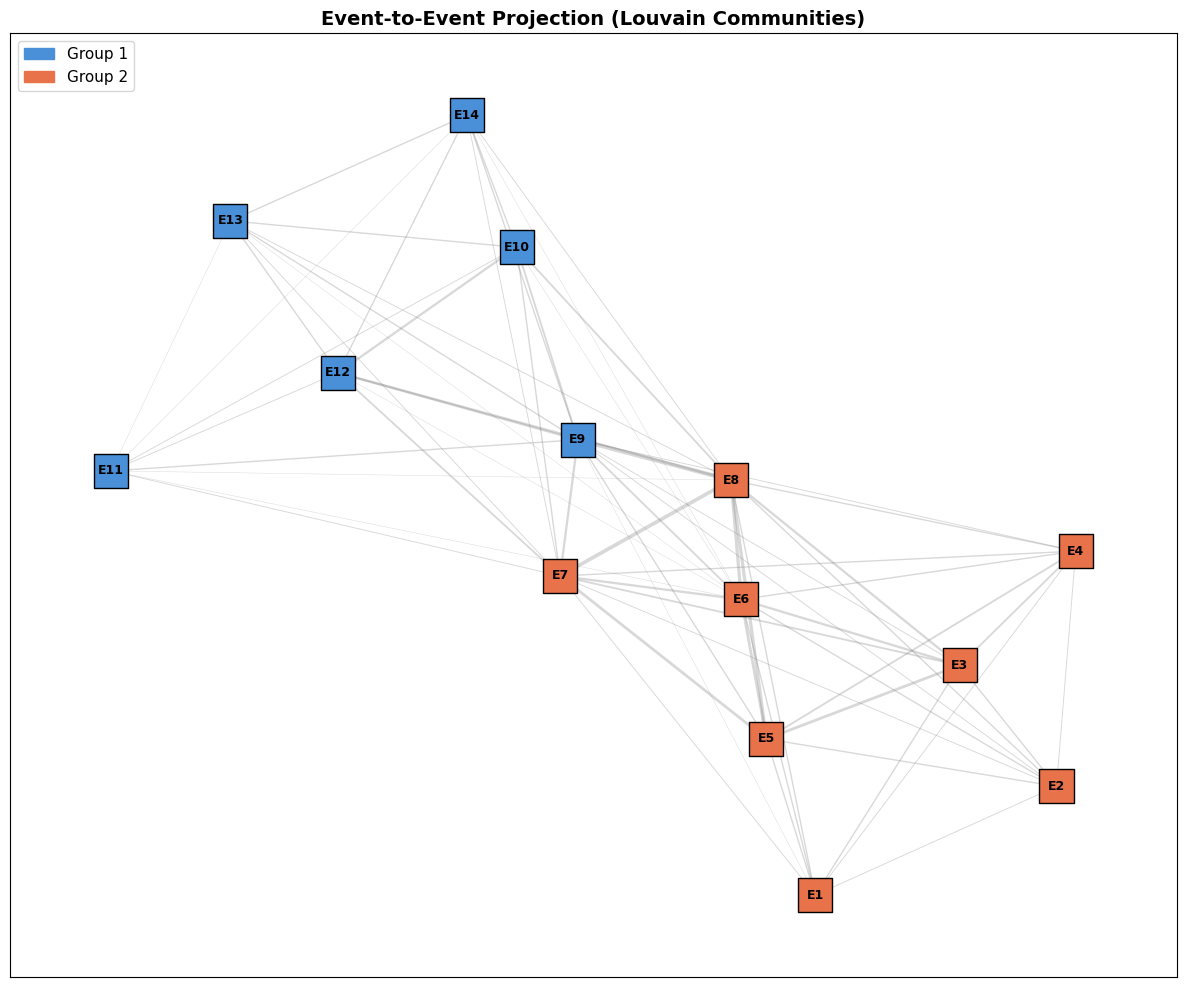

Event Group 1: ['E10', 'E11', 'E12', 'E13', 'E14', 'E9']
Event Group 2: ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8']


In [9]:
# Project onto events
E = bipartite.weighted_projected_graph(G, events)

print(f"Events network: {E.number_of_nodes()} nodes, {E.number_of_edges()} edges")
print(f"Density: {nx.density(E):.3f}")

# Community detection on events network
partition_events = community_louvain.best_partition(E, random_state=42)

node_colors_e = [community_colors_map.get(partition_events[n], '#888888') for n in E.nodes()]

fig, ax = plt.subplots(figsize=(12, 10))
pos_e = nx.spring_layout(E, seed=42, k=1.0)

edges_e = E.edges(data=True)
edge_weights_e = [d['weight'] for _, _, d in edges_e]
max_we = max(edge_weights_e)

nx.draw_networkx_edges(E, pos_e, alpha=0.3, width=[w/max_we*3 for w in edge_weights_e],
                       edge_color='gray', ax=ax)
nx.draw_networkx_nodes(E, pos_e, node_color=node_colors_e, node_size=600,
                       node_shape='s', edgecolors='black', linewidths=1.0, ax=ax)
nx.draw_networkx_labels(E, pos_e, font_size=9, font_weight='bold', ax=ax)

event_communities = set(partition_events.values())
patches_e = [mpatches.Patch(color=community_colors_map[c], label=f'Group {c+1}') for c in sorted(event_communities)]
ax.legend(handles=patches_e, loc='upper left', fontsize=11)
ax.set_title('Event-to-Event Projection (Louvain Communities)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for c in sorted(event_communities):
    members = [n for n, comm in partition_events.items() if comm == c]
    print(f"Event Group {c+1}: {sorted(members)}")

## 8. Centrality Analysis: Events Network

In [10]:
deg_cent_e = nx.degree_centrality(E)
betw_cent_e = nx.betweenness_centrality(E, weight='weight')
eigen_cent_e = nx.eigenvector_centrality(E, weight='weight', max_iter=1000)

print(f"{'Event':<10} {'Degree':>8} {'Betweenness':>12} {'Eigenvector':>12}")
print("-" * 45)
for e in sorted(events):
    print(f"{e:<10} {deg_cent_e[e]:>8.3f} {betw_cent_e[e]:>12.3f} {eigen_cent_e[e]:>12.3f}")

print(f"\nMost central event by eigenvector: {max(eigen_cent_e, key=eigen_cent_e.get)}")
print(f"Most central event by betweenness: {max(betw_cent_e, key=betw_cent_e.get)}")

Event        Degree  Betweenness  Eigenvector
---------------------------------------------
E1            0.615        0.048        0.168
E10           0.615        0.000        0.187
E11           0.615        0.093        0.101
E12           0.615        0.000        0.216
E13           0.615        0.011        0.132
E14           0.615        0.011        0.132
E2            0.615        0.025        0.177
E3            0.615        0.000        0.277
E4            0.615        0.000        0.203
E5            0.615        0.000        0.333
E6            1.000        0.292        0.339
E7            1.000        0.029        0.377
E8            1.000        0.014        0.453
E9            1.000        0.124        0.352

Most central event by eigenvector: E8
Most central event by betweenness: E6


## 9. Hierarchical Clustering

Using hierarchical clustering on the co-occurrence matrices to validate the community structure.

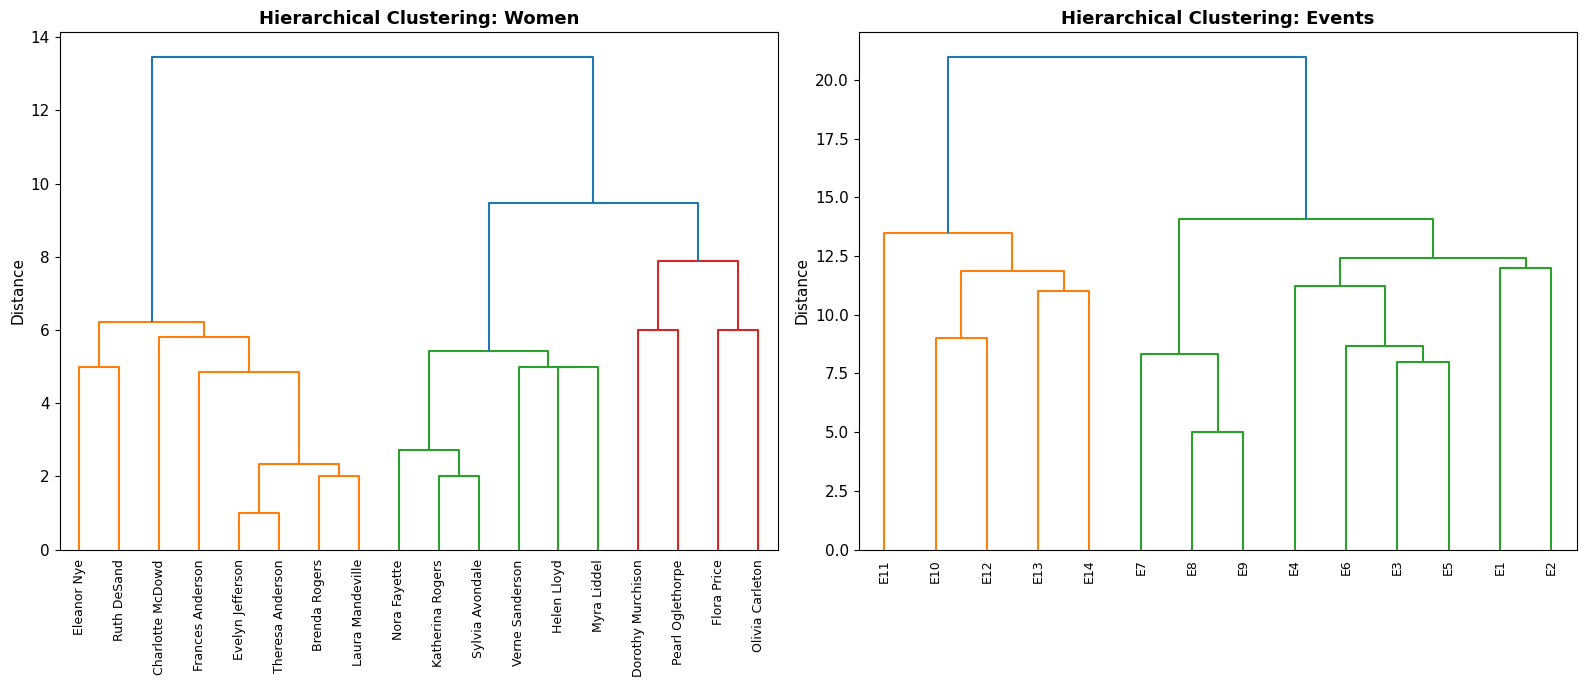

In [11]:
# Hierarchical clustering of women based on co-attendance
co_women = adj_matrix @ adj_matrix.T  # women x women co-occurrence matrix

# Convert similarity to distance
max_coatt = co_women.max()
dist_women = max_coatt - co_women
np.fill_diagonal(dist_women, 0)

# Linkage and dendrogram
condensed_w = squareform(dist_women)
Z_women = linkage(condensed_w, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

dendrogram(Z_women, labels=women_sorted, leaf_rotation=90, leaf_font_size=9, ax=axes[0])
axes[0].set_title('Hierarchical Clustering: Women', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Distance')

# Hierarchical clustering of events
co_events = adj_matrix.T @ adj_matrix  # events x events co-occurrence matrix
max_coev = co_events.max()
dist_events = max_coev - co_events
np.fill_diagonal(dist_events, 0)

condensed_e = squareform(dist_events)
Z_events = linkage(condensed_e, method='ward')

dendrogram(Z_events, labels=events_sorted, leaf_rotation=90, leaf_font_size=9, ax=axes[1])
axes[1].set_title('Hierarchical Clustering: Events', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Distance')

plt.tight_layout()
plt.show()

## 10. Co-occurrence Heatmaps

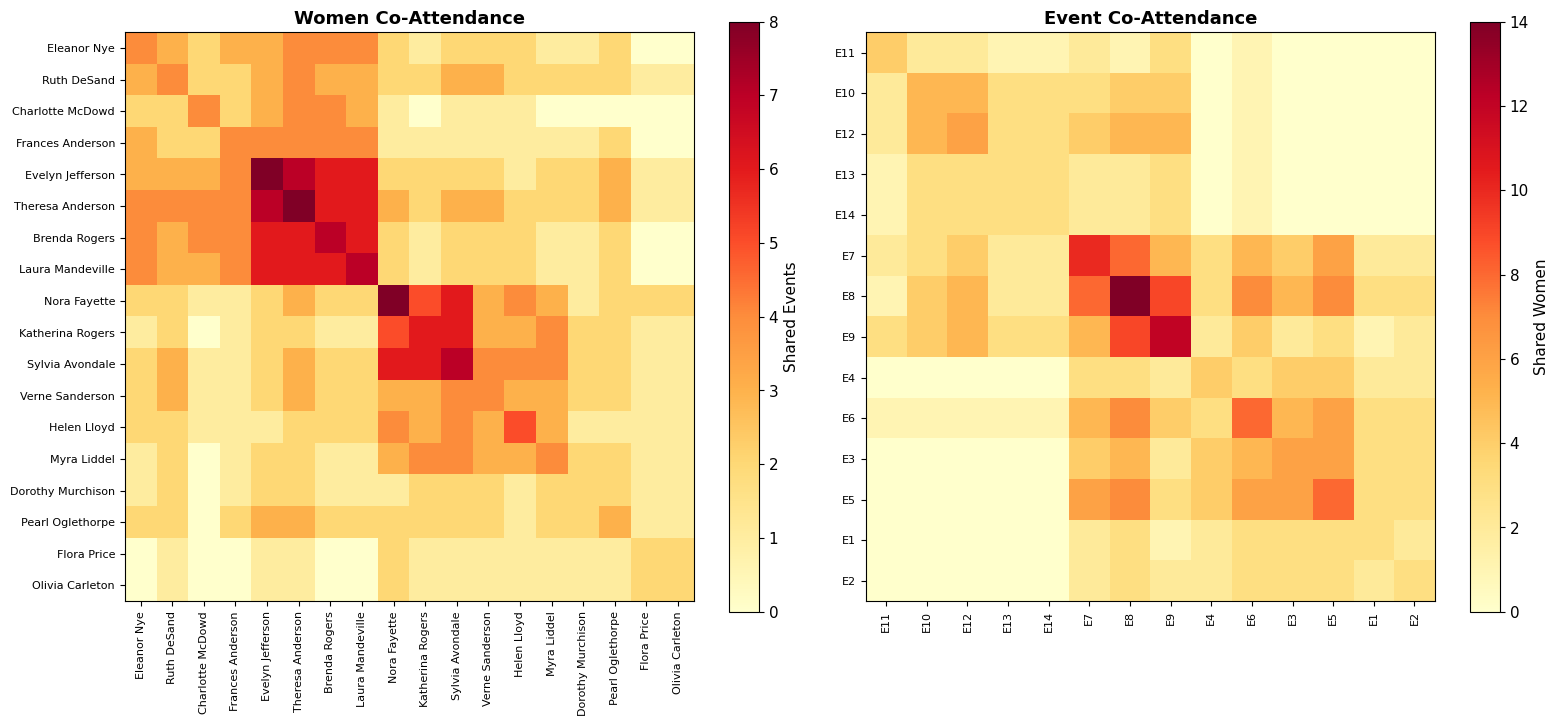

In [12]:
# Reorder by cluster for visual clarity
from scipy.cluster.hierarchy import leaves_list

women_order = leaves_list(Z_women)
events_order = leaves_list(Z_events)

women_reordered = [women_sorted[i] for i in women_order]
events_reordered = [events_sorted[i] for i in events_order]

co_women_reordered = co_women[np.ix_(women_order, women_order)]
co_events_reordered = co_events[np.ix_(events_order, events_order)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

im1 = axes[0].imshow(co_women_reordered, cmap='YlOrRd')
axes[0].set_xticks(range(len(women_reordered)))
axes[0].set_xticklabels(women_reordered, rotation=90, fontsize=8)
axes[0].set_yticks(range(len(women_reordered)))
axes[0].set_yticklabels(women_reordered, fontsize=8)
axes[0].set_title('Women Co-Attendance', fontsize=13, fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='Shared Events')

im2 = axes[1].imshow(co_events_reordered, cmap='YlOrRd')
axes[1].set_xticks(range(len(events_reordered)))
axes[1].set_xticklabels(events_reordered, rotation=90, fontsize=8)
axes[1].set_yticks(range(len(events_reordered)))
axes[1].set_yticklabels(events_reordered, fontsize=8)
axes[1].set_title('Event Co-Attendance', fontsize=13, fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='Shared Women')

plt.tight_layout()
plt.show()

## 11. Network Statistics Summary

In [13]:
print("=" * 55)
print("NETWORK SUMMARY STATISTICS")
print("=" * 55)

print("\n--- Bipartite Network ---")
print(f"Women nodes: {len(women)}")
print(f"Event nodes: {len(events)}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {bipartite.density(G, women):.3f}")

print("\n--- Women Projection ---")
print(f"Nodes: {W.number_of_nodes()}, Edges: {W.number_of_edges()}")
print(f"Density: {nx.density(W):.3f}")
print(f"Avg clustering coefficient: {nx.average_clustering(W, weight='weight'):.3f}")
print(f"Transitivity: {nx.transitivity(W):.3f}")
print(f"Communities (Louvain): {len(set(partition_women.values()))}")
print(f"Modularity: {community_louvain.modularity(partition_women, W):.3f}")

print("\n--- Events Projection ---")
print(f"Nodes: {E.number_of_nodes()}, Edges: {E.number_of_edges()}")
print(f"Density: {nx.density(E):.3f}")
print(f"Avg clustering coefficient: {nx.average_clustering(E, weight='weight'):.3f}")
print(f"Transitivity: {nx.transitivity(E):.3f}")
print(f"Communities (Louvain): {len(set(partition_events.values()))}")
print(f"Modularity: {community_louvain.modularity(partition_events, E):.3f}")

NETWORK SUMMARY STATISTICS

--- Bipartite Network ---
Women nodes: 18
Event nodes: 14
Edges: 89
Density: 0.353

--- Women Projection ---
Nodes: 18, Edges: 139
Density: 0.908
Avg clustering coefficient: 0.289
Transitivity: 0.928
Communities (Louvain): 2
Modularity: 0.152

--- Events Projection ---
Nodes: 14, Edges: 66
Density: 0.725
Avg clustering coefficient: 0.309
Transitivity: 0.831
Communities (Louvain): 2
Modularity: 0.172


## 12. Analysis and Inferences

### Relationships Between Women

The analysis reveals a clear **two-group structure** among the 18 women, consistent with decades of prior research on this dataset:

**Group 1** (roughly Evelyn, Laura, Theresa, Brenda, Charlotte, Frances, Eleanor, Pearl, Ruth) tended to attend earlier events (E1 through E9). These women show high co-attendance with each other and form a dense subnetwork.

**Group 2** (roughly Verne, Myra, Katherine, Sylvia, Nora, Helen, Dorothy, Olivia, Flora) attended later events (E6 through E14). Their co-attendance patterns are largely distinct from Group 1.

Notably, a few women (such as Theresa, Brenda, and Sylvia) act as **bridges** between the two groups, attending events from both clusters. These women have elevated betweenness centrality, confirming their structural brokerage role.

The **eigenvector centrality** analysis identifies the most socially embedded women: those who not only attend many events but attend events with other highly connected women. This gives a richer picture than raw attendance count alone.

### Relationships Between Events

Events also cluster into two groups mirroring the women's social structure:

**Event Cluster 1** (earlier events like E1, E2, E3, E4, E5) were attended predominantly by Group 1 women.

**Event Cluster 2** (later events like E10, E11, E12, E13, E14) were attended predominantly by Group 2 women.

**Middle events** (E6, E7, E8, E9) show the highest betweenness centrality because they were attended by women from *both* groups, making them the connective tissue of the social fabric.

### Key Takeaways

1. The bipartite structure encodes rich social information: attendance patterns reveal latent community structure without needing explicit friendship data.
2. Both Louvain community detection and hierarchical clustering converge on the same two-group partition, validating the robustness of this finding.
3. The co-occurrence heatmaps (reordered by cluster) make the block-diagonal structure visually obvious, confirming tight within-group cohesion.
4. Bridge individuals and bridge events are identifiable through betweenness centrality, offering insight into the social dynamics that connect otherwise separate circles.